# Sionna RT Scenario Visualization

This notebook visualizes all scenarios defined in `heatmap_situations.py`, showing:
- Building positions and geometry
- Transmitter location (red)
- RIS points (blue)
- Receiver locations (green)
- Propagation paths (rays) between actors

Each scenario is loaded from its corresponding XML file in `mesh_scene/` and rendered with Sionna RT.

## Setup and Imports

In [1]:
import os
import numpy as np
import pandas as pd
from IPython.display import display

# Import Sionna RT components
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera, PathSolver, mi

# Import situation definitions
from heatmap_situations import situations

navigable_preview = False

print("✓ Imports successful")

✓ Imports successful


## Visualization Function

In [2]:
def visualize_scenario(situation, render_resolution=(1200, 900), num_samples=256):
    """
    Visualize a single scenario with buildings, actors, and propagation paths.
    
    Args:
        situation: Situation dictionary from heatmap_situations.py
        render_resolution: Tuple of (width, height) for rendered image
        num_samples: Number of samples for ray tracing (higher = better quality)
    """
    simulation_name = situation['simulation_name']
    scene_path = f"mesh_scene/{simulation_name}.xml"
    
    if not os.path.exists(scene_path):
        print(f"❌ Error: Scene file not found: {scene_path}")
        return
    
    print(f"\n{'='*60}")
    print(f"{simulation_name}")
    print(f"{'='*60}")
    print(f"Scene: {situation['width']}m × {situation['height']}m | "
          f"Buildings: {len(situation['buildings'])} | "
          f"RIS: {len(situation['ris_points'])} | "
          f"Receivers: {len(situation['receivers'])}")
    
    # Load scene
    scene = load_scene(scene_path)
    scene.frequency = 3.5e9
    
    # Configure antenna arrays (simple isotropic for visualization)
    scene.tx_array = PlanarArray(
        num_rows=1,
        num_cols=1,
        vertical_spacing=0.5,
        horizontal_spacing=0.5,
        pattern="iso",
        polarization="V"
    )
    
    scene.rx_array = PlanarArray(
        num_rows=1,
        num_cols=1,
        vertical_spacing=0.5,
        horizontal_spacing=0.5,
        pattern="iso",
        polarization="V"
    )
    
    # Add Transmitter (RED)
    tx_point = situation['transmitter']
    tx = Transmitter(
        name="TX",
        position=mi.Point3f([tx_point['x'], tx_point['y'], 1.5]),
        orientation=mi.Point3f([0.0, 0.0, 0.0]),
        display_radius=0.5,
        color=[1.0, 0.0, 0.0]  # Red
    )
    scene.add(tx)
    
    # Add RIS Points (BLUE)
    for i, ris_point in enumerate(situation['ris_points']):
        ris = Receiver(
            name=f"RIS{i+1}",
            position=mi.Point3f([ris_point['x'], ris_point['y'], 1.5]),
            orientation=mi.Point3f([0.0, 0.0, 0.0]),
            display_radius=0.4,
            color=[0.0, 0.0, 1.0]  # Blue
        )
        scene.add(ris)
    
    # Add Receivers (GREEN)
    for i, receiver in enumerate(situation['receivers']):
        rx = Receiver(
            name=f"RX{i+1}",
            position=mi.Point3f([receiver['x'], receiver['y'], 1.5]),
            orientation=mi.Point3f([0.0, 0.0, 0.0]),
            display_radius=0.3,
            color=[0.0, 1.0, 0.0]  # Green
        )
        scene.add(rx)
    
    # Setup camera position (improved bird's eye view)
    center_x = situation['width'] / 2
    center_y = situation['height'] / 2
    max_dim = max(situation['width'], situation['height'])

    camera_height = max_dim * 2
    camera_offset = max_dim * 0.15  # Slight offset for subtle 3D
    look_at_height = 5.0  # Actor height level

    camera = Camera(
        position=mi.Point3f([center_x - camera_offset, center_y - camera_offset, camera_height]),
        look_at=mi.Point3f([center_x, center_y, look_at_height])
    )
    
    # Compute propagation paths
    print("Computing paths and rendering...")
    path_solver = PathSolver()
    
    try:
        paths = path_solver(
            scene=scene,
            max_depth=3,
            los=True,
            specular_reflection=True,
            diffuse_reflection=False,
            refraction=True,
            synthetic_array=True,
            seed=42
        )
        
        # Render scene with paths (Jupyter auto-displays)
        if not navigable_preview:
            scene.render(
                camera=camera,
                paths=paths,
                resolution=render_resolution,
                num_samples=num_samples,
                clip_at=max(30, camera_height * 1.5)
            )
        else:
            scene.preview()
        
        print(f"✓ Complete\n")
        
    except Exception as e:
        print(f"⚠ Warning: Could not compute paths: {e}")
        print("Rendering without paths...")
        
        # Render without paths (Jupyter auto-displays)
        if not navigable_preview:
            scene.render(
                camera=camera,
                resolution=render_resolution,
                num_samples=num_samples,
                clip_at=max(30, camera_height * 1.5)
            )
        else:
            scene.preview()
        
        print(f"✓ Complete\n")
    
    # Clean up
    # del scene, path_solver

print("✓ Visualization function loaded")

✓ Visualization function loaded


## Visualize All Scenarios

The following cell will visualize each scenario in the situations list.

**Color Legend:**
- 🔴 **Red sphere** = Transmitter (TX)
- 🔵 **Blue spheres** = RIS Points (RIS1, RIS2, ...)
- 🟢 **Green spheres** = Receivers (RX1, RX2, ...)
- **Colored rays** = Propagation paths

SCENARIO VISUALIZATION

Found 5 scenarios to visualize


[1/5]

Single Reflection
Scene: 20m × 20m | Buildings: 2 | RIS: 1 | Receivers: 2
Computing paths and rendering...
✓ Complete


[2/5]

Single Reflection BIG
Scene: 2000m × 2000m | Buildings: 2 | RIS: 1 | Receivers: 2
Computing paths and rendering...
✓ Complete


[3/5]

RISs in series, only final
Scene: 20m × 20m | Buildings: 2 | RIS: 2 | Receivers: 2
Computing paths and rendering...
✓ Complete


[4/5]

RISs in series
Scene: 20m × 20m | Buildings: 5 | RIS: 3 | Receivers: 5
Computing paths and rendering...
✓ Complete


[5/5]

RISs in parallel
Scene: 20m × 20m | Buildings: 4 | RIS: 5 | Receivers: 3
Computing paths and rendering...
✓ Complete


✓ All visualizations complete!


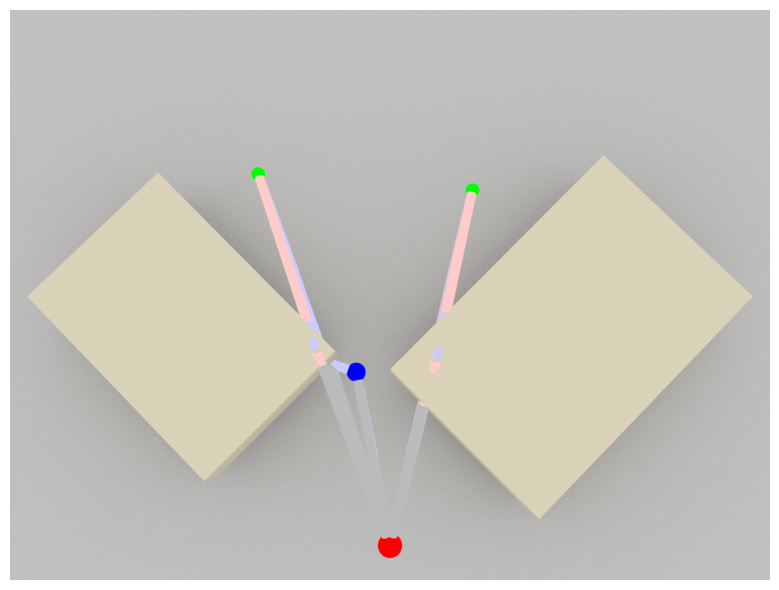

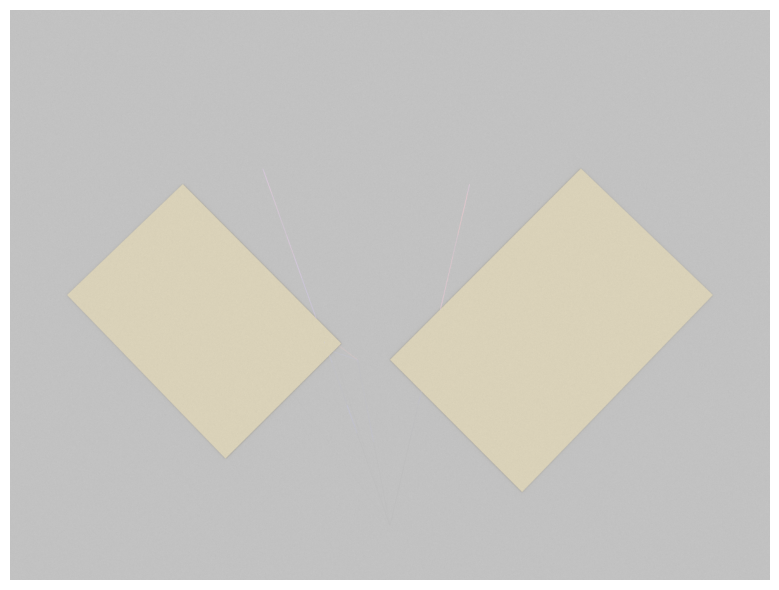

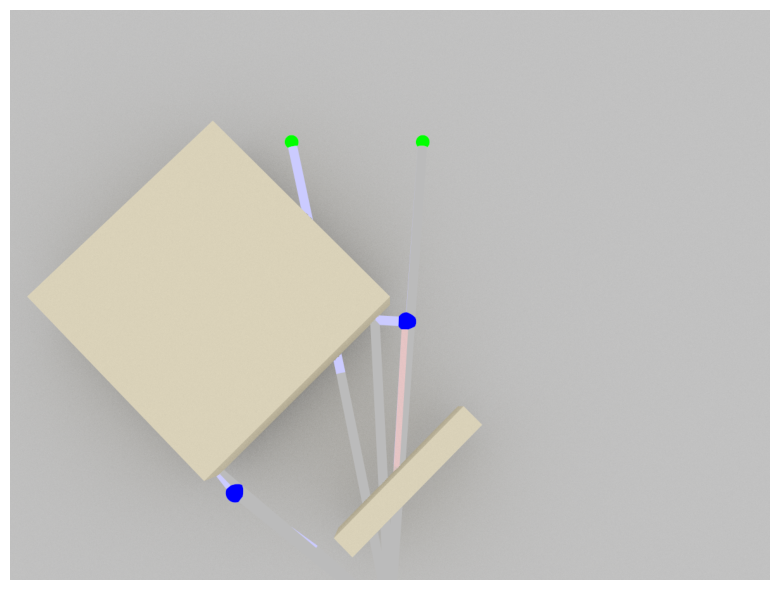

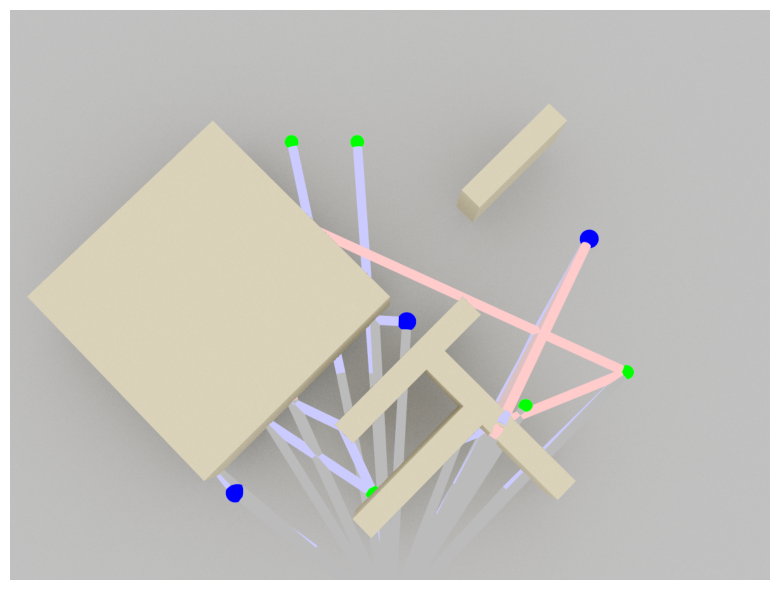

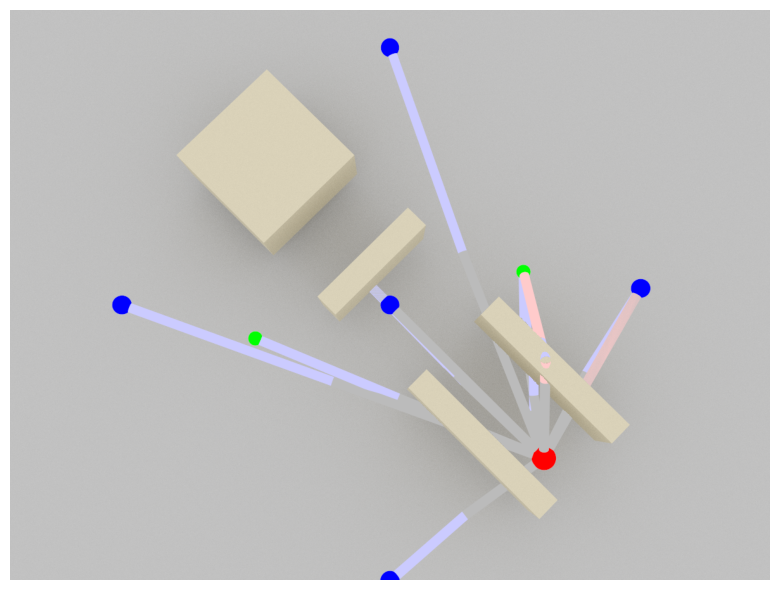

In [3]:
# Visualize all scenarios marked with calculate=True
should_do_all = True
if should_do_all:
    print("="*60)
    print("SCENARIO VISUALIZATION")
    print("="*60)

    scenarios_to_visualize = [s for s in situations if s['calculate']]
    print(f"\nFound {len(scenarios_to_visualize)} scenarios to visualize\n")

    for i, situation in enumerate(scenarios_to_visualize, 1):
        print(f"\n[{i}/{len(scenarios_to_visualize)}]")
        try:
            visualize_scenario(situation, render_resolution=(1200, 900), num_samples=256)
            
        except Exception as e:
            print(f"❌ Error visualizing {situation['simulation_name']}: {e}")
            import traceback
            traceback.print_exc()

    print("\n" + "="*60)
    print("✓ All visualizations complete!")
    print("="*60)

## Visualize Individual Scenario

Use this cell to visualize a specific scenario by name with higher quality settings.


High-Quality Render (Single Reflection)

Single Reflection
Scene: 20m × 20m | Buildings: 2 | RIS: 1 | Receivers: 2
Computing paths and rendering...
✓ Complete



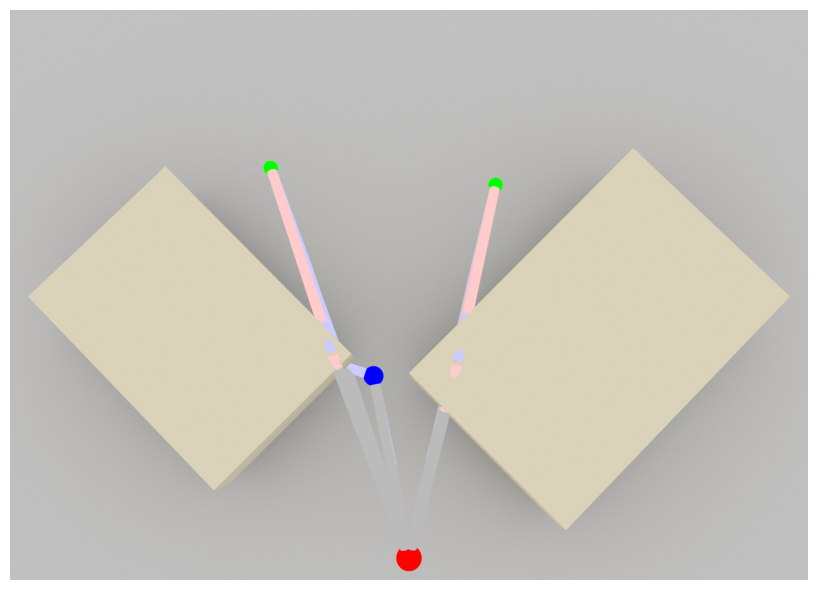

In [4]:
# Visualize a specific scenario by name
scenario_name = "Single Reflection"  # Change this to visualize different scenarios

situation = next((s for s in situations if s['simulation_name'] == scenario_name), None)

if situation:
    print(f"\nHigh-Quality Render ({scenario_name})")
    visualize_scenario(situation, render_resolution=(1400, 1000), num_samples=512)
else:
    print(f"Scenario '{scenario_name}' not found.")
    print("\nAvailable scenarios:")
    for s in situations:
        print(f"  - {s['simulation_name']}")

## Scene Information Summary

In [5]:
# Display summary table of all scenarios
summary_data = []
for situation in situations:
    summary_data.append({
        'Scenario': situation['simulation_name'],
        'Calculate': '✓' if situation['calculate'] else '✗',
        'Size (m)': f"{situation['width']}×{situation['height']}",
        'Resolution (m)': situation['resolution'],
        'Buildings': len(situation['buildings']),
        'RIS Points': len(situation['ris_points']),
        'Receivers': len(situation['receivers']),
    })

df = pd.DataFrame(summary_data)
print("\nScenario Summary:")
print("="*80)
display(df)


Scenario Summary:


,Scenario,Calculate,Size (m),Resolution (m),Buildings,RIS Points,Receivers
0,Single Reflection,✓,20×20,0.5,2,1,2
1,Single Reflection BIG,✓,2000×2000,50.0,2,1,2
2,Single Reflection - Clustered Receivers,✗,20×20,0.5,2,1,3
3,"RISs in series, only final",✓,20×20,0.5,2,2,2
4,RISs in series,✓,20×20,0.5,5,3,5
5,RISs in parallel,✓,20×20,0.5,4,5,3
